# Notebook 3 — Daily Loop: State and Feedback

**Phase I of the Lockport gas turbine digital twin build.** Prove the
recursive feedback architecture works: today's dispatch updates stress
accumulators that feed tomorrow's degraded heat rate + capacity + forced
outage probability, which feeds tomorrow's dispatch decision.

**Plan**: [`docs/plans/consolidation_plan/notebooks/03_daily_loop_feedback.md`](../docs/plans/consolidation_plan/notebooks/03_daily_loop_feedback.md)

**Inherited from Notebooks 1, 2 + ADR-001**:
- `v()` / `m()` helpers; weather TZ conversion
- Henry Hub direct (ADR-001); RGGI at $17/short ton CO2; 117 lb CO2/MMBtu
- Mode capacities from `engineering.yaml`; mode heat rates from `operating_profile.yaml`
- Mode-choice heuristic from N2

**New in N3**: state evolution, twin dispatch (clean vs degraded), forced-outage
probability from state, 4 diagnostic plots, ambient derate, cogen VOM markup.
Inspection event triggering + LTSA accrual + outage event sampling deferred to N4.

## Conventions chosen for this notebook (decision log)

| Decision | Choice |
|---|---|
| Window size | 30 days |
| Window picker | 2023 summer (Jun-Sep) high-LMP window, full 720h non-null |
| State grain | Block-level (single state for whole CCGT) |
| Initial state | Prototype defaults (24,000 EOH; Weibull β=3, η=28,000 TBC; rotor_life 0.35) |
| Inspection events | **Headroom tracked only**; no triggering (deferred to N4) |
| Forced outage events | **Probability computed only**; no sampling (deferred to N4) |
| Ambient derate | Linear interp between summer derate and winter boost per generator |
| Cogen VOM markup | ×1.35 multiplier on base $1.02/MWh → $1.38/MWh |
| Cogen DHTS must-run | Synthetic flag: must-run on coldest 20% of days in window (proxy until MOR extraction) |
| Min-load enforcement | None (each mode dispatches at full capacity if economic) |
| Mode-switch stickiness | None (add only if §I sanity check fails) |
| Twin dispatch | Compute spark_clean and spark_degraded; loss_degradation = clean - degraded |
| Prototype constants | Inherited as-is; Lockport-override opportunities flagged in §K findings |

---
## §A — Setup

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any
from dataclasses import dataclass, field, replace

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

REPO_ROOT = Path("..").resolve()
DATA_DIR = REPO_ROOT / "data"
ASSET = "lockport"


# ---- Helper functions (same as N1, N2) ----
def v(field: Any) -> Any:
    if isinstance(field, dict) and "value" in field and "status" in field:
        return field["value"]
    return field


def m(field: Any) -> dict | None:
    if isinstance(field, dict) and "value" in field and "status" in field:
        return {k: val for k, val in field.items() if k != "value"}
    return None


# ---- Load all the inputs ----
def load_yaml(name: str) -> dict:
    return yaml.safe_load((DATA_DIR / "assets" / ASSET / f"{name}.yaml").read_text())

identity = load_yaml("identity")
engineering = load_yaml("engineering")
market_context = load_yaml("market_context")
operating_profile = load_yaml("operating_profile")
ltsa_terms = load_yaml("ltsa_terms")

tech_defaults = pd.read_parquet(DATA_DIR / "tech_class_defaults" / "dispatch_params_lookup.parquet")

PATHS_DIR = DATA_DIR / "paths" / ASSET
lmp_da = pd.read_parquet(PATHS_DIR / "lmp_da_hourly.parquet")
gas = pd.read_parquet(PATHS_DIR / "gas_price_history.parquet")
weather_raw = pd.read_parquet(PATHS_DIR / "weather_hourly.parquet")
weather = weather_raw.copy()
weather.index = pd.to_datetime(weather.index, utc=True).tz_convert("US/Eastern")

print("Data spine loaded.")

Data spine loaded.


### Constants (prototype convention; Lockport-override opportunities flagged for N4)

In [2]:
# Mode heat rates from operating_profile.yaml (MOR-derived, real_observed)
HR_3xCC = float(v(operating_profile["heat_rate_by_mode"]["3xCC_full"]["btu_per_kwh"]))
HR_2xCC = float(v(operating_profile["heat_rate_by_mode"]["2xCC"]["btu_per_kwh"]))
HR_1xCC = float(v(operating_profile["heat_rate_by_mode"]["1xCC"]["btu_per_kwh"]))

# Mode capacities from engineering.yaml
gens = engineering["generators"]
NAMEPLATE_CT = float(v(gens["GEN1"]["nameplate_capacity_mw"]))
NAMEPLATE_CA = float(v(gens["GEN4"]["nameplate_capacity_mw"]))

MODES = {
    "3xCC_full": {"hr_btu_per_kwh": HR_3xCC, "capacity_mw": 3 * NAMEPLATE_CT + NAMEPLATE_CA},
    "2xCC":      {"hr_btu_per_kwh": HR_2xCC, "capacity_mw": 2 * NAMEPLATE_CT + NAMEPLATE_CA},
    "1xCC":      {"hr_btu_per_kwh": HR_1xCC, "capacity_mw": 1 * NAMEPLATE_CT + NAMEPLATE_CA},
}

# Base VOM + cogen markup
VOM_BASE_USD_PER_MWH = float(tech_defaults[
    (tech_defaults["prime_mover_code"] == "CT")
    & (tech_defaults["vintage_class"] == "<2000")
    & (~tech_defaults["aero_derivative"])
].iloc[0]["vom_per_mwh"])
COGEN_VOM_MARKUP = 1.35  # midpoint of +30-50% range per caveats.md §2
VOM_USD_PER_MWH = VOM_BASE_USD_PER_MWH * COGEN_VOM_MARKUP

# RGGI
RGGI_USD_PER_SHORT_TON_CO2 = 17.0
RGGI_CO2_LB_PER_MMBTU_NG = 117.0
RGGI_COST_PER_MMBTU = (RGGI_CO2_LB_PER_MMBTU_NG / 2000) * RGGI_USD_PER_SHORT_TON_CO2

# ---- Lockport-specific cold-start warming gas (per ADR-002 Correction 1) ----
# When a cold start occurs, real Lockport plant burns gas during HRSG warming
# BEFORE producing MWh. MOR observed 35 such "warming days" over 5 yr at
# 2,537 MMBtu/start average. Without this, fuel cost is under-counted on
# cold-start days. real_observed from operating_profile.yaml.cold_start_gas.
MOR_COLD_START_GAS_MMBTU = float(v(operating_profile["cold_start_gas"]["mean_per_cold_start_mmbtu"]))

# Inspection thresholds from ltsa_terms.yaml (currently placeholders)
CI_EOH_THRESHOLD = float(v(ltsa_terms["inspection_ci"]["eoh_threshold"]))
MI_EOH_THRESHOLD = float(v(ltsa_terms["inspection_mi"]["eoh_threshold"]))

# ---- Engineering state-evolution constants (prototype convention) ----
# EOH counting per start type (GER-3620K approximate)
START_EOH_COST = {"cold": 20.0, "warm": 10.0, "hot": 5.0}

# Fouling: exponential approach to asymptote (CI water wash resets 70%)
FOULING_ASYMPTOTE_PCT = 2.5
FOULING_TAU_HRS = 2000.0
FOULING_AQI_PROXY = 1.0  # we don't have AQI in the data spine; flag for v2

# Creep (Robinson)
CREEP_RATE_PER_FIRED_HOUR = 5e-6  # base rate; accelerated by overfiring (not modeled in v1)
CREEP_BUDGET = 1.0

# Fatigue (Miner)
FATIGUE_PER_COLD_START = 0.001
FATIGUE_PER_WARM_START = 0.0005
FATIGUE_PER_HOT_START = 0.0002
FATIGUE_BUDGET = 1.0
COMB_BUDGET = 1.0  # combined damage threshold (same as fatigue budget for this model)

# Creep-fatigue interaction envelope
D_LIM = 0.7  # in mixed regime if both dc and df > 0.05

# HRSG
HRSG_CYCLES_PER_START = 1.0
HRSG_BASE_PROB_PER_DAY = 0.0075
HRSG_AGE_MULT_MAX = 1.5  # 1.0× → 1.5× over 10 years

# Background (non-GT non-HRSG: controls, generator, BOP)
BG_BASE_PROB_PER_DAY = 0.004
BG_AGE_MULT_MAX = 1.5

# Rotor
ROTOR_LIFE_PER_FIRED_HOUR = 1e-7

# Forced outage hockey-stick
P_COMBUSTION_INFLECTION = 0.6
P_COMBUSTION_SCALE = 0.10
P_FORCED_DAY_CAP = 0.10  # cap at 10%/day per prototype convention

# TBC Weibull params
TBC_WEIBULL_BETA = 3.0
TBC_WEIBULL_ETA = 28_000.0

print(f"Constants loaded. Mode HRs: 3xCC={HR_3xCC}, 2xCC={HR_2xCC}, 1xCC={HR_1xCC}")
print(f"Mode capacities: 3xCC={MODES['3xCC_full']['capacity_mw']:.1f}, 2xCC={MODES['2xCC']['capacity_mw']:.1f}, 1xCC={MODES['1xCC']['capacity_mw']:.1f}")
print(f"VOM with cogen markup: ${VOM_USD_PER_MWH:.2f}/MWh (base ${VOM_BASE_USD_PER_MWH:.2f} × {COGEN_VOM_MARKUP})")
print(f"RGGI adder: ${RGGI_COST_PER_MMBTU:.3f}/MMBtu")
print(f"Inspection thresholds: CI={CI_EOH_THRESHOLD}, MI={MI_EOH_THRESHOLD} EOH (placeholders per ltsa_terms.yaml)")

Constants loaded. Mode HRs: 3xCC=8901.0, 2xCC=9598.0, 1xCC=10424.0
Mode capacities: 3xCC=221.3, 2xCC=172.6, 1xCC=123.9
VOM with cogen markup: $1.38/MWh (base $1.02 × 1.35)
RGGI adder: $0.995/MMBtu
Inspection thresholds: CI=24000.0, MI=48000.0 EOH (placeholders per ltsa_terms.yaml)


---
## §B — Window picker (30-day window)

Strategy: find a 2023 summer month with at least 15 high-LMP days; pick a
30-day window starting from the first high-LMP day of that month; require
all 720 hours non-null.

In [3]:
lmp_2023 = lmp_da[lmp_da["datetime_local"].dt.year == 2023].copy()
lmp_2023["date"] = lmp_2023["datetime_local"].dt.date
lmp_2023["month"] = lmp_2023["datetime_local"].dt.month

# Daily peak LMP per 2023 day
daily_peak_2023 = lmp_2023.groupby("date").agg(
    peak_lmp=("price", "max"),
    n_hours=("price", "count"),
    null_count=("price", lambda x: x.isna().sum()),
    month=("month", "first"),
).reset_index()

# Find summer (Jun-Sep) month with most high-LMP days (peak > P75)
p75_2023 = daily_peak_2023["peak_lmp"].quantile(0.75)
summer_high = daily_peak_2023[
    (daily_peak_2023["month"].between(6, 9))
    & (daily_peak_2023["peak_lmp"] > p75_2023)
    & (daily_peak_2023["n_hours"] >= 24)
    & (daily_peak_2023["null_count"] == 0)
]
month_counts = summer_high.groupby("month").size()
print(f"2023 P75 daily peak LMP: ${p75_2023:.2f}/MWh")
print(f"High-LMP-day count by summer month: {month_counts.to_dict()}")

# Pick the month with the most high-LMP days
chosen_month = int(month_counts.idxmax())
first_high_lmp_day = summer_high[summer_high["month"] == chosen_month].sort_values("date").iloc[0]["date"]
print(f"Chosen month: {chosen_month}; first high-LMP day: {first_high_lmp_day}")

# 30-day window starting from that day
window_start = pd.Timestamp(first_high_lmp_day)
window_end = window_start + pd.Timedelta(days=30)

# Verify full 720 hours non-null
window_lmp = lmp_2023[
    (lmp_2023["datetime_local"] >= window_start.tz_localize("US/Eastern"))
    & (lmp_2023["datetime_local"] < window_end.tz_localize("US/Eastern"))
].sort_values("datetime_local").reset_index(drop=True)
print(f"Window: {window_start.date()} → {window_end.date()} ({len(window_lmp)} hours)")
assert len(window_lmp) == 720, f"Expected 720 hours, got {len(window_lmp)}"
assert window_lmp["price"].notna().all(), "Null LMPs in window"

# Per-day summary for the window
window_lmp["date"] = window_lmp["datetime_local"].dt.date
window_days_summary = window_lmp.groupby("date").agg(
    peak_lmp=("price", "max"),
    mean_lmp=("price", "mean"),
).reset_index()
print(f"\nWindow daily LMP summary:")
print(window_days_summary.describe().round(1).to_string())

2023 P75 daily peak LMP: $41.33/MWh
High-LMP-day count by summer month: {6: 4, 7: 24, 8: 2, 9: 5}
Chosen month: 7; first high-LMP day: 2023-07-01
Window: 2023-07-01 → 2023-07-31 (720 hours)

Window daily LMP summary:
       peak_lmp  mean_lmp
count      30.0      30.0
mean       58.8      35.8
std        33.0      11.6
min        30.7      24.5
25%        41.7      29.7
50%        49.3      32.9
75%        59.5      37.5
max       200.6      85.6


---
## §C — State vector + initialization

In [4]:
@dataclass
class PlantState:
    """Plant state vector. Mirrors prototype's init_state (per understanding doc §6),
    extended for Lockport's 3-on-1 block-level state grain (v1 simplification).
    """
    # Engineering state
    eoh: float = 24_000.0
    hr_recov: float = 0.0       # %; resets partially at CI, strongly at MI
    fouling: float = 0.0        # %; asymptote 2.5%, CI water wash resets 70%
    dc: float = 0.0             # creep damage (Robinson)
    df: float = 0.0             # fatigue damage (Miner)
    tbc_time: float = 0.0       # TBC time at temp (hrs)
    tbc_thresh: float = TBC_WEIBULL_ETA  # path-specific Weibull threshold
    hrsg_cycles: float = 0.0
    rotor_life: float = 0.35

    # Operational continuity (carries hour-by-hour through the day)
    op: bool = False
    hrs_off: float = 24.0
    run_hrs: float = 0.0
    last_stype: str = "cold"

    # Inspection tracking
    insp_done: int = 0


def init_state(seed: int = 42) -> PlantState:
    """Day-0 state for Lockport.
    Inherits prototype's Athens-derived defaults for v1. Lockport-specific
    LTSA-derived overrides are an N4/v2 concern.
    """
    rng = np.random.default_rng(seed)
    return PlantState(tbc_thresh=float(TBC_WEIBULL_ETA * rng.weibull(TBC_WEIBULL_BETA)))


state0 = init_state(seed=42)
print(f"Initial state: eoh={state0.eoh}, hr_recov={state0.hr_recov}%, fouling={state0.fouling}%, "
      f"dc={state0.dc:.4f}, df={state0.df:.4f}, tbc_thresh={state0.tbc_thresh:.0f}, "
      f"rotor_life={state0.rotor_life}")

Initial state: eoh=24000.0, hr_recov=0.0%, fouling=0.0%, dc=0.0000, df=0.0000, tbc_thresh=37510, rotor_life=0.35


---
## §D — Daily loop helpers

### §D.1 — Effective parameters

In [5]:
def ambient_derate_factor(temp_f: float, gen: dict) -> float:
    """Linear interpolation between summer derate and winter boost.
    Summer at 90°F: nameplate * (1 - summer_derate_pct/100)
    Winter at 32°F: nameplate * (1 + winter_boost_pct/100)
    """
    summer_derate = v(gen["summer_derate_pct"])
    winter_boost = v(gen["winter_boost_pct"])
    # Interpolate by temperature (90°F = full summer derate; 32°F = full winter boost)
    if temp_f >= 90:
        return 1.0 - summer_derate / 100
    if temp_f <= 32:
        return 1.0 + winter_boost / 100
    # Linear between
    frac = (temp_f - 32) / (90 - 32)
    return (1.0 + winter_boost / 100) + frac * ((1.0 - summer_derate / 100) - (1.0 + winter_boost / 100))


def hr_clean_for_mode(mode_name: str) -> float:
    """Clean reference heat rate by mode (no degradation)."""
    return MODES[mode_name]["hr_btu_per_kwh"]


def hr_degraded_for_mode(mode_name: str, state: PlantState) -> float:
    """Degraded heat rate = clean × (1 + hr_recov/100) × (1 + fouling/100)."""
    return hr_clean_for_mode(mode_name) * (1 + state.hr_recov / 100) * (1 + state.fouling / 100)


def cap_eff_for_mode(mode_name: str, temp_f: float) -> float:
    """Capacity-effective for a mode at given ambient temperature.
    For v1, apply a single derate factor (avg of GEN1 and GEN4 for the block).
    """
    derate_ct = ambient_derate_factor(temp_f, gens["GEN1"])
    derate_ca = ambient_derate_factor(temp_f, gens["GEN4"])
    # Block-level: capacity-weighted average derate
    if mode_name == "3xCC_full":
        ct_cap = 3 * NAMEPLATE_CT * derate_ct
        ca_cap = NAMEPLATE_CA * derate_ca
    elif mode_name == "2xCC":
        ct_cap = 2 * NAMEPLATE_CT * derate_ct
        ca_cap = NAMEPLATE_CA * derate_ca
    elif mode_name == "1xCC":
        ct_cap = NAMEPLATE_CT * derate_ct
        ca_cap = NAMEPLATE_CA * derate_ca
    else:
        return 0.0
    return ct_cap + ca_cap

### §D.2 — Dispatch (reuse N2's logic in function form)

In [6]:
def dispatch_day(
    state: PlantState,
    hourly_inputs: pd.DataFrame,
    gas_henry_hub: float,
    must_run: bool,
    use_degraded_hr: bool,
) -> dict:
    """Dispatch a 24-hour day.
    Returns dict with: total_mwh, total_fuel_mmbtu, gross_margin_usd, mode_sequence,
    starts (list of types), fired_hours, total_loss_degradation_usd.
    """
    delivered_fuel_per_mmbtu = gas_henry_hub + RGGI_COST_PER_MMBTU

    mode_seq = []
    mw_seq = []
    revenue = 0.0
    fuel_mmbtu_total = 0.0
    starts: list[str] = []

    # Track operational continuity hour-by-hour (within this day)
    op = state.op
    hrs_off = state.hrs_off

    for _, row in hourly_inputs.iterrows():
        lmp = row["lmp"]
        temp_f = row["temp_f"]

        # Compute spark for each mode
        best_mode = None
        best_margin = -float("inf")
        best_mw = 0.0
        for mode_name in MODES:
            hr = hr_degraded_for_mode(mode_name, state) if use_degraded_hr else hr_clean_for_mode(mode_name)
            cap_mw = cap_eff_for_mode(mode_name, temp_f)
            fuel_cost = hr / 1000 * delivered_fuel_per_mmbtu
            spark = lmp - fuel_cost - VOM_USD_PER_MWH
            margin = max(spark, 0) * cap_mw
            if margin > best_margin:
                best_margin = margin
                best_mode = mode_name
                best_mw = cap_mw

        # Apply must-run if no mode is economic
        if best_margin <= 0:
            if must_run:
                # Force 1xCC at whatever spark it has (negative)
                mode = "1xCC"
                hr = hr_degraded_for_mode(mode, state) if use_degraded_hr else hr_clean_for_mode(mode)
                cap_mw = cap_eff_for_mode(mode, temp_f)
                fuel_cost = hr / 1000 * delivered_fuel_per_mmbtu
                spark = lmp - fuel_cost - VOM_USD_PER_MWH
                margin_realized = spark * cap_mw
                mw_dispatched = cap_mw
            else:
                mode = "offline"
                margin_realized = 0.0
                mw_dispatched = 0.0
        else:
            mode = best_mode
            margin_realized = best_margin
            mw_dispatched = best_mw

        # Detect start event
        if mode != "offline" and not op:
            # Plant starts this hour
            if hrs_off < 8:
                stype = "hot"
            elif hrs_off < 72:
                stype = "warm"
            else:
                stype = "cold"
            starts.append(stype)
            op = True
            hrs_off = 0.0
        elif mode == "offline" and op:
            # Plant shuts down
            op = False
            hrs_off = 1.0
        elif mode == "offline":
            hrs_off += 1.0
        else:
            pass  # remains on

        # Accumulate
        if mode != "offline":
            hr_used = hr_degraded_for_mode(mode, state) if use_degraded_hr else hr_clean_for_mode(mode)
            fuel_mmbtu = mw_dispatched * hr_used / 1000
            fuel_mmbtu_total += fuel_mmbtu
            revenue += lmp * mw_dispatched
        mode_seq.append(mode)
        mw_seq.append(mw_dispatched)

    fired_hours = sum(1 for mh in mode_seq if mh != "offline")
    total_mwh = sum(mw_seq)
    fuel_cost_total = fuel_mmbtu_total * gas_henry_hub
    rggi_cost_total = fuel_mmbtu_total * RGGI_COST_PER_MMBTU
    vom_cost_total = total_mwh * VOM_USD_PER_MWH
    gross_margin = revenue - fuel_cost_total - rggi_cost_total - vom_cost_total

    return {
        "total_mwh": total_mwh,
        "fired_hours": fired_hours,
        "starts": starts,
        "mode_sequence": mode_seq,
        "fuel_mmbtu_total": fuel_mmbtu_total,
        "revenue_usd": revenue,
        "fuel_cost_usd": fuel_cost_total,
        "rggi_cost_usd": rggi_cost_total,
        "vom_cost_usd": vom_cost_total,
        "gross_margin_usd": gross_margin,
        "ending_op": op,
        "ending_hrs_off": hrs_off,
    }

### §D.3 — Stress accumulator update

In [7]:
def update_stress(state: PlantState, fired_hours: float, starts: list[str], avg_temp_f: float) -> None:
    """Update state's stress accumulators in-place after a day's dispatch."""
    # EOH counting: fired hours + start penalties
    start_eoh = sum(START_EOH_COST.get(s, 10.0) for s in starts)
    state.eoh += fired_hours + start_eoh

    # Fouling: exponential approach to asymptote
    if fired_hours > 0:
        delta = (FOULING_ASYMPTOTE_PCT - state.fouling) * (fired_hours / FOULING_TAU_HRS) * FOULING_AQI_PROXY
        state.fouling = min(FOULING_ASYMPTOTE_PCT, state.fouling + delta)

    # HR recoverable degradation (HGP wear) — slow drift up with fired hours
    state.hr_recov += fired_hours * 1e-5 * 100  # ~0.001% per fired hour; ~0.7%/year if running 700 hrs

    # Creep damage (Robinson) — proportional to fired hours
    state.dc += CREEP_RATE_PER_FIRED_HOUR * fired_hours

    # Fatigue damage (Miner) — proportional to starts
    for stype in starts:
        if stype == "cold":
            state.df += FATIGUE_PER_COLD_START
        elif stype == "warm":
            state.df += FATIGUE_PER_WARM_START
        elif stype == "hot":
            state.df += FATIGUE_PER_HOT_START

    # Creep-fatigue interaction envelope
    if state.dc > 0.05 and state.df > 0.05 and (state.dc + state.df) > D_LIM:
        # Inspection-equivalent halving (proxy)
        state.dc *= 0.5
        state.df *= 0.5

    # TBC time accumulates with fired hours
    state.tbc_time += fired_hours

    # HRSG cycles per start
    state.hrsg_cycles += HRSG_CYCLES_PER_START * len(starts)

    # Rotor life consumed
    state.rotor_life += ROTOR_LIFE_PER_FIRED_HOUR * fired_hours

    # Update operational flags
    if starts:
        state.last_stype = starts[-1]

### §D.4 — Forced outage probability

In [8]:
def p_forced_components(state: PlantState, year_frac: float = 0.1) -> dict:
    """Compute P_forced decomposed by component (per understanding doc §7)."""
    # P_GT components
    # Combustion: hockey-stick after 60% of fatigue budget
    excess = max(0.0, state.df / COMB_BUDGET - P_COMBUSTION_INFLECTION)
    p_comb = min(P_COMBUSTION_SCALE * (excess ** 2), P_FORCED_DAY_CAP)

    # TBC: 1.0 if past threshold; Weibull hazard rate below
    if state.tbc_time >= state.tbc_thresh:
        p_tbc = 1.0
    else:
        # Conditional Weibull hazard rate (β=3): h(t) = β/η × (t/η)^(β-1)
        # Per-day: integrate over 24 hours
        t = state.tbc_time
        if t > 0:
            p_tbc = (TBC_WEIBULL_BETA / TBC_WEIBULL_ETA) * (t / TBC_WEIBULL_ETA) ** (TBC_WEIBULL_BETA - 1) * 24
            p_tbc = min(p_tbc, P_FORCED_DAY_CAP)
        else:
            p_tbc = 0.0

    # Rotor
    p_rotor = 0.00003 * state.rotor_life

    # GT total
    p_gt = p_comb + p_tbc + p_rotor

    # HRSG (age-scaled)
    age_mult_hrsg = 1.0 + year_frac * (HRSG_AGE_MULT_MAX - 1.0)
    p_hrsg = HRSG_BASE_PROB_PER_DAY * age_mult_hrsg

    # Background (controls, generator, BOP)
    age_mult_bg = 1.0 + year_frac * (BG_AGE_MULT_MAX - 1.0)
    p_bg = BG_BASE_PROB_PER_DAY * age_mult_bg

    # Combined (independence assumption)
    p_combined = 1 - (1 - min(p_gt, 1.0)) * (1 - min(p_hrsg, 1.0)) * (1 - min(p_bg, 1.0))

    return {
        "p_combustion": p_comb,
        "p_tbc": p_tbc,
        "p_rotor": p_rotor,
        "p_gt": p_gt,
        "p_hrsg": p_hrsg,
        "p_bg": p_bg,
        "p_combined": p_combined,
    }

### §D.5 — The day loop

In [9]:
# Build per-day inputs for the 30-day window
window_lmp_indexed = window_lmp.set_index("datetime_local")
window_weather = weather.loc[
    (weather.index >= window_start.tz_localize("US/Eastern"))
    & (weather.index < window_end.tz_localize("US/Eastern"))
].copy()

# Convert weather temp_c → temp_f
window_weather["temp_f"] = window_weather["temperature_2m"] * 9 / 5 + 32

# Henry Hub for the window: nearest prior trade for each day
henry = gas[gas["hub_name"] == "Henry Hub"].copy()
henry["trade_date_dt"] = pd.to_datetime(henry["trade_date"]).dt.date

# Cogen must-run flag: coldest 20% of days in the window
daily_mean_temp = window_weather.groupby(window_weather.index.date)["temp_f"].mean()
cold_threshold = daily_mean_temp.quantile(0.20)
must_run_days = set(daily_mean_temp[daily_mean_temp <= cold_threshold].index)
print(f"Cogen must-run synthetic flag: days with mean temp ≤ ${cold_threshold:.1f}°F → {len(must_run_days)} days flagged")
print(f"  Must-run dates: {sorted(must_run_days)[:5]}{'...' if len(must_run_days) > 5 else ''}")

# Run the day loop
state = init_state(seed=42)
state_history = [replace(state)]
daily_records = []

dates = pd.date_range(window_start, window_end - pd.Timedelta(hours=1), freq="D")
for day_idx, day in enumerate(dates):
    day_date = day.date()
    day_start_eastern = pd.Timestamp(day_date, tz="US/Eastern")
    day_end_eastern = day_start_eastern + pd.Timedelta(hours=24)

    # Slice hourly inputs for this day
    day_lmp_slice = window_lmp[
        (window_lmp["datetime_local"] >= day_start_eastern)
        & (window_lmp["datetime_local"] < day_end_eastern)
    ].sort_values("datetime_local").reset_index(drop=True)
    day_weather_slice = window_weather.loc[
        (window_weather.index >= day_start_eastern)
        & (window_weather.index < day_end_eastern)
    ].copy()

    # Build hourly DataFrame
    hourly = pd.DataFrame({
        "hour": range(24),
        "lmp": day_lmp_slice["price"].values[:24] if len(day_lmp_slice) >= 24 else day_lmp_slice["price"].values,
        "temp_f": day_weather_slice["temp_f"].values[:24] if len(day_weather_slice) >= 24 else day_weather_slice["temp_f"].values,
    })
    if len(hourly) < 24:
        # Pad with mean values if a partial day (shouldn't happen with our window-validation)
        hourly = hourly.reindex(range(24), method="ffill").reset_index(drop=True)

    # Henry Hub for this day (nearest prior)
    hh_match = henry[henry["trade_date_dt"] <= day_date].sort_values("trade_date_dt").tail(1)
    gas_hh = float(hh_match.iloc[0]["price_usd_per_mmbtu"])

    # Must-run flag
    must_run_today = day_date in must_run_days

    # === Twin dispatch ===
    # Clean reference (no degradation)
    dr_clean = dispatch_day(state, hourly, gas_hh, must_run_today, use_degraded_hr=False)
    # Degraded actual
    dr_degraded = dispatch_day(state, hourly, gas_hh, must_run_today, use_degraded_hr=True)

    # === Apply Lockport-specific cold-start warming gas (ADR-002 Correction 1) ===
    # Real MOR-observed warming gas burned BEFORE the plant generates MWh on a cold start.
    # Apply to both clean and degraded paths (warming gas is a real cost regardless of degradation).
    delivered_gas = gas_hh + RGGI_COST_PER_MMBTU
    cold_starts_clean = sum(1 for s in dr_clean["starts"] if s == "cold")
    cold_starts_degraded = sum(1 for s in dr_degraded["starts"] if s == "cold")
    warming_gas_mmbtu_clean = cold_starts_clean * MOR_COLD_START_GAS_MMBTU
    warming_gas_mmbtu_degraded = cold_starts_degraded * MOR_COLD_START_GAS_MMBTU
    warming_fuel_cost_clean = warming_gas_mmbtu_clean * gas_hh
    warming_rggi_cost_clean = warming_gas_mmbtu_clean * RGGI_COST_PER_MMBTU
    warming_fuel_cost_degraded = warming_gas_mmbtu_degraded * gas_hh
    warming_rggi_cost_degraded = warming_gas_mmbtu_degraded * RGGI_COST_PER_MMBTU
    warming_total_clean = warming_fuel_cost_clean + warming_rggi_cost_clean
    warming_total_degraded = warming_fuel_cost_degraded + warming_rggi_cost_degraded
    dr_clean["gross_margin_usd"] -= warming_total_clean
    dr_degraded["gross_margin_usd"] -= warming_total_degraded
    dr_clean["warming_cost_usd"] = warming_total_clean
    dr_degraded["warming_cost_usd"] = warming_total_degraded

    # Loss attribution (after warming-gas applied to both paths)
    loss_degradation = dr_clean["gross_margin_usd"] - dr_degraded["gross_margin_usd"]

    # === Inspection threshold preview ===
    eoh_to_ci = max(0.0, CI_EOH_THRESHOLD - state.eoh)
    eoh_to_mi = max(0.0, MI_EOH_THRESHOLD - state.eoh)

    # === Forced outage probability ===
    year_frac = day_idx / 365.0
    pf = p_forced_components(state, year_frac=year_frac)

    # === Commit dispatch state changes ===
    state.op = dr_degraded["ending_op"]
    state.hrs_off = dr_degraded["ending_hrs_off"]
    if dr_degraded["starts"]:
        state.last_stype = dr_degraded["starts"][-1]

    # === Update stress accumulators ===
    avg_temp_f = float(hourly["temp_f"].mean())
    update_stress(state, dr_degraded["fired_hours"], dr_degraded["starts"], avg_temp_f)

    # Record
    daily_records.append({
        "day_idx": day_idx,
        "date": day_date,
        "lmp_mean": hourly["lmp"].mean(),
        "lmp_peak": hourly["lmp"].max(),
        "temp_mean_f": avg_temp_f,
        "gas_hh": gas_hh,
        "must_run": must_run_today,
        "mwh_clean": dr_clean["total_mwh"],
        "mwh_degraded": dr_degraded["total_mwh"],
        "margin_clean": dr_clean["gross_margin_usd"],
        "margin_degraded": dr_degraded["gross_margin_usd"],
        "loss_degradation": loss_degradation,
        "cold_starts_degraded": cold_starts_degraded,
        "warming_cost_degraded": warming_total_degraded,
        "fired_hours": dr_degraded["fired_hours"],
        "starts_count": len(dr_degraded["starts"]),
        "mode_3x_hours": dr_degraded["mode_sequence"].count("3xCC_full"),
        "mode_2x_hours": dr_degraded["mode_sequence"].count("2xCC"),
        "mode_1x_hours": dr_degraded["mode_sequence"].count("1xCC"),
        "offline_hours": dr_degraded["mode_sequence"].count("offline"),
        "eoh_to_ci": eoh_to_ci,
        "eoh_to_mi": eoh_to_mi,
        **pf,
        "eoh": state.eoh,
        "hr_recov": state.hr_recov,
        "fouling": state.fouling,
        "dc": state.dc,
        "df": state.df,
        "tbc_time": state.tbc_time,
        "tbc_thresh": state.tbc_thresh,
        "hrsg_cycles": state.hrsg_cycles,
        "rotor_life": state.rotor_life,
    })
    state_history.append(replace(state))

daily = pd.DataFrame(daily_records)
print(f"\n30-day loop completed.")
print(f"  Total MWh dispatched (degraded): {daily['mwh_degraded'].sum():,.0f}")
print(f"  Total fired hours: {daily['fired_hours'].sum()}")
print(f"  Total starts: {daily['starts_count'].sum()}")
print(f"  Total cold starts: {daily['cold_starts_degraded'].sum()}")
print(f"  Total warming gas cost (ADR-002 correction): ${daily['warming_cost_degraded'].sum():,.0f}")
print(f"  Total gross margin (degraded, AFTER warming gas correction): ${daily['margin_degraded'].sum():,.0f}")
print(f"  Cumulative loss to degradation: ${daily['loss_degradation'].sum():,.0f}")

Cogen must-run synthetic flag: days with mean temp ≤ $69.8°F → 6 days flagged
  Must-run dates: [datetime.date(2023, 7, 8), datetime.date(2023, 7, 9), datetime.date(2023, 7, 19), datetime.date(2023, 7, 21), datetime.date(2023, 7, 29)]...



30-day loop completed.
  Total MWh dispatched (degraded): 83,948
  Total fired hours: 415
  Total starts: 27
  Total cold starts: 0
  Total warming gas cost (ADR-002 correction): $0
  Total gross margin (degraded, AFTER warming gas correction): $913,254
  Cumulative loss to degradation: $11,535


---
## §E — Plot 1: State trajectory (3-panel)

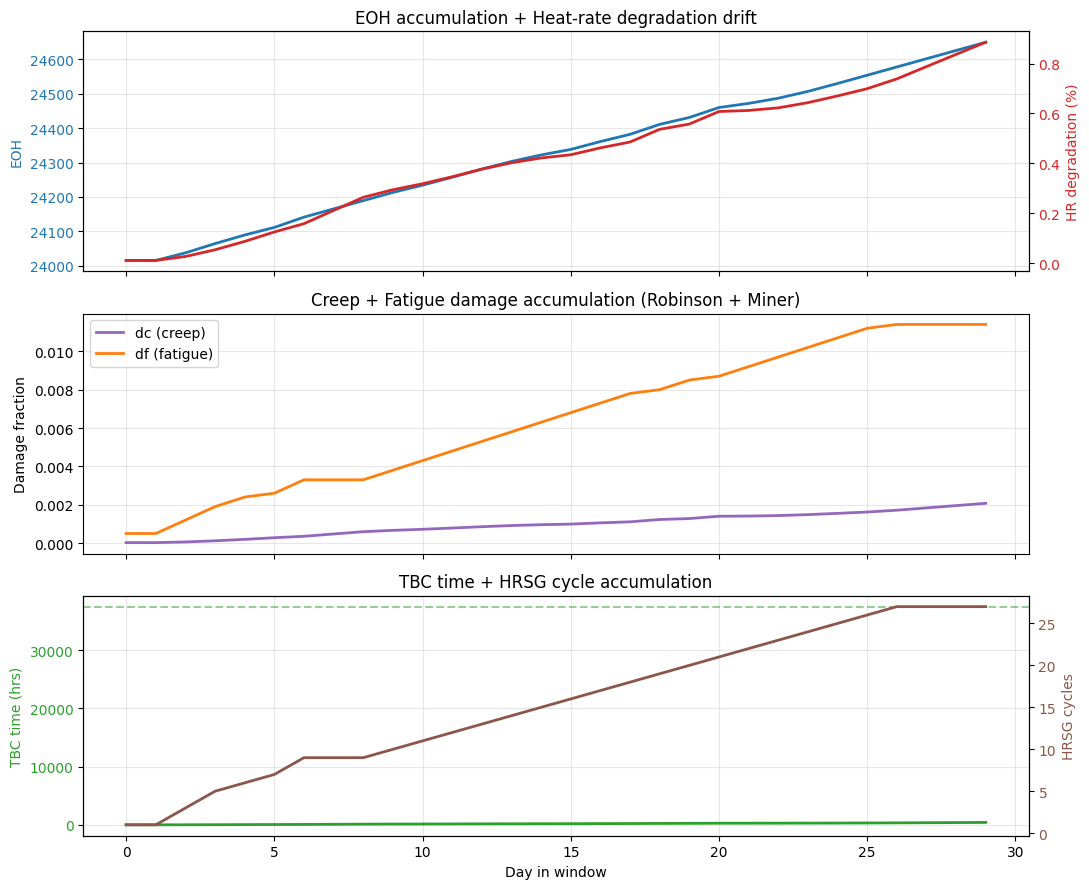

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# Panel 1: EOH + HR degradation
ax1 = axes[0]
ax1.plot(daily["day_idx"], daily["eoh"], color="tab:blue", linewidth=2, label="EOH")
ax1.set_ylabel("EOH", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1_t = ax1.twinx()
ax1_t.plot(daily["day_idx"], daily["hr_recov"] + daily["fouling"], color="tab:red", linewidth=2, label="HR degradation %")
ax1_t.set_ylabel("HR degradation (%)", color="tab:red")
ax1_t.tick_params(axis="y", labelcolor="tab:red")
ax1.set_title("EOH accumulation + Heat-rate degradation drift")
ax1.grid(alpha=0.3)

# Panel 2: Creep + Fatigue
ax2 = axes[1]
ax2.plot(daily["day_idx"], daily["dc"], color="tab:purple", linewidth=2, label="dc (creep)")
ax2.plot(daily["day_idx"], daily["df"], color="tab:orange", linewidth=2, label="df (fatigue)")
ax2.set_ylabel("Damage fraction")
ax2.set_title("Creep + Fatigue damage accumulation (Robinson + Miner)")
ax2.legend(loc="upper left")
ax2.grid(alpha=0.3)

# Panel 3: TBC + HRSG cycles
ax3 = axes[2]
ax3.plot(daily["day_idx"], daily["tbc_time"], color="tab:green", linewidth=2, label="TBC time-at-temp (hrs)")
ax3.axhline(daily["tbc_thresh"].iloc[0], color="tab:green", linestyle="--", alpha=0.5,
            label=f"TBC threshold (path-specific, {daily['tbc_thresh'].iloc[0]:.0f})")
ax3.set_ylabel("TBC time (hrs)", color="tab:green")
ax3.tick_params(axis="y", labelcolor="tab:green")
ax3_t = ax3.twinx()
ax3_t.plot(daily["day_idx"], daily["hrsg_cycles"], color="tab:brown", linewidth=2, label="HRSG cycles")
ax3_t.set_ylabel("HRSG cycles", color="tab:brown")
ax3_t.tick_params(axis="y", labelcolor="tab:brown")
ax3.set_xlabel("Day in window")
ax3.set_title("TBC time + HRSG cycle accumulation")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## §F — Plot 2: Forced outage probability decomposition

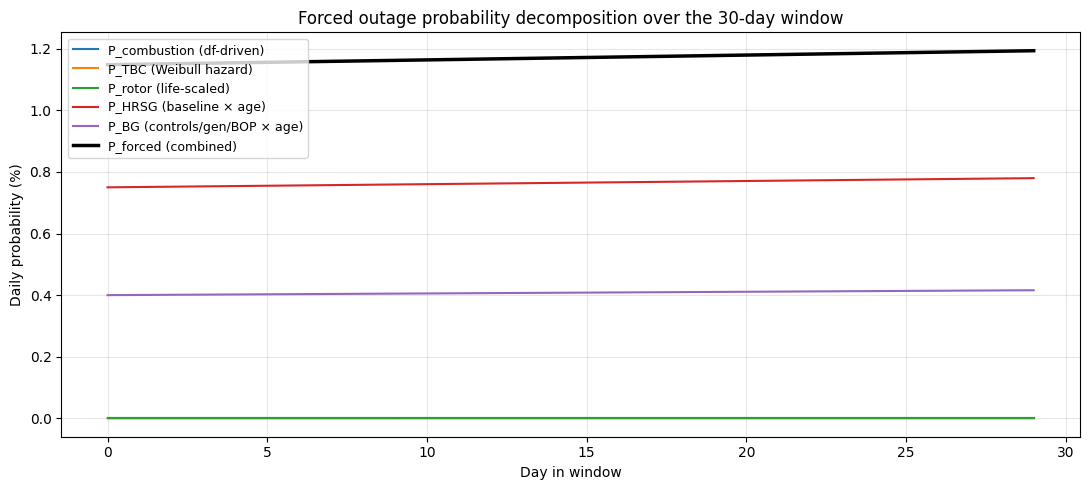

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(daily["day_idx"], daily["p_combustion"] * 100, label="P_combustion (df-driven)", linewidth=1.5)
ax.plot(daily["day_idx"], daily["p_tbc"] * 100, label="P_TBC (Weibull hazard)", linewidth=1.5)
ax.plot(daily["day_idx"], daily["p_rotor"] * 100, label="P_rotor (life-scaled)", linewidth=1.5)
ax.plot(daily["day_idx"], daily["p_hrsg"] * 100, label="P_HRSG (baseline × age)", linewidth=1.5)
ax.plot(daily["day_idx"], daily["p_bg"] * 100, label="P_BG (controls/gen/BOP × age)", linewidth=1.5)
ax.plot(daily["day_idx"], daily["p_combined"] * 100, label="P_forced (combined)", linewidth=2.5, color="black")
ax.set_xlabel("Day in window")
ax.set_ylabel("Daily probability (%)")
ax.set_title("Forced outage probability decomposition over the 30-day window")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## §G — Plot 3: Daily MWh by mode + cumulative gross margin

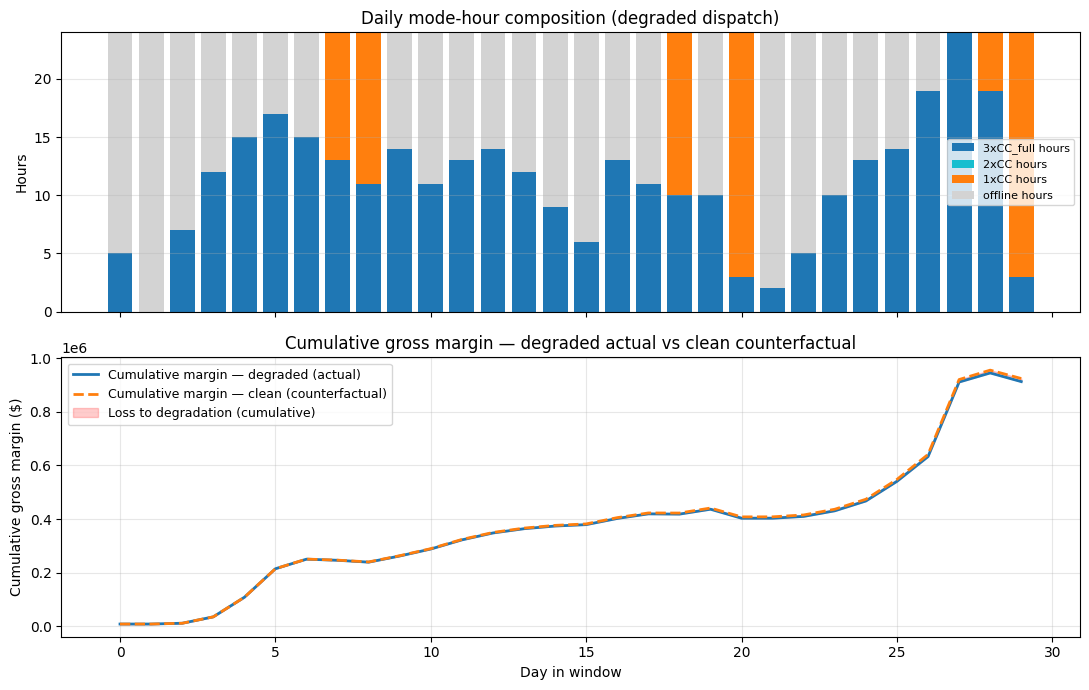

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Panel 1: stacked bar of mode-hours per day
ax1 = axes[0]
x = daily["day_idx"]
b0 = ax1.bar(x, daily["mode_3x_hours"], label="3xCC_full hours", color="tab:blue")
b1 = ax1.bar(x, daily["mode_2x_hours"], bottom=daily["mode_3x_hours"], label="2xCC hours", color="tab:cyan")
b2 = ax1.bar(x, daily["mode_1x_hours"], bottom=daily["mode_3x_hours"] + daily["mode_2x_hours"], label="1xCC hours", color="tab:orange")
b3 = ax1.bar(x, daily["offline_hours"], bottom=daily["mode_3x_hours"] + daily["mode_2x_hours"] + daily["mode_1x_hours"], label="offline hours", color="lightgray")
ax1.set_ylabel("Hours")
ax1.set_title("Daily mode-hour composition (degraded dispatch)")
ax1.legend(loc="center right", fontsize=8)
ax1.grid(alpha=0.3, axis="y")

# Panel 2: cumulative gross margin
ax2 = axes[1]
ax2.plot(daily["day_idx"], daily["margin_degraded"].cumsum(), label="Cumulative margin — degraded (actual)", linewidth=2)
ax2.plot(daily["day_idx"], daily["margin_clean"].cumsum(), label="Cumulative margin — clean (counterfactual)", linewidth=2, linestyle="--")
ax2.fill_between(daily["day_idx"], daily["margin_degraded"].cumsum(), daily["margin_clean"].cumsum(),
                 alpha=0.2, color="red", label="Loss to degradation (cumulative)")
ax2.set_xlabel("Day in window")
ax2.set_ylabel("Cumulative gross margin ($)")
ax2.set_title("Cumulative gross margin — degraded actual vs clean counterfactual")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## §H — Plot 4: Daily clean vs degraded daily margin + loss attribution

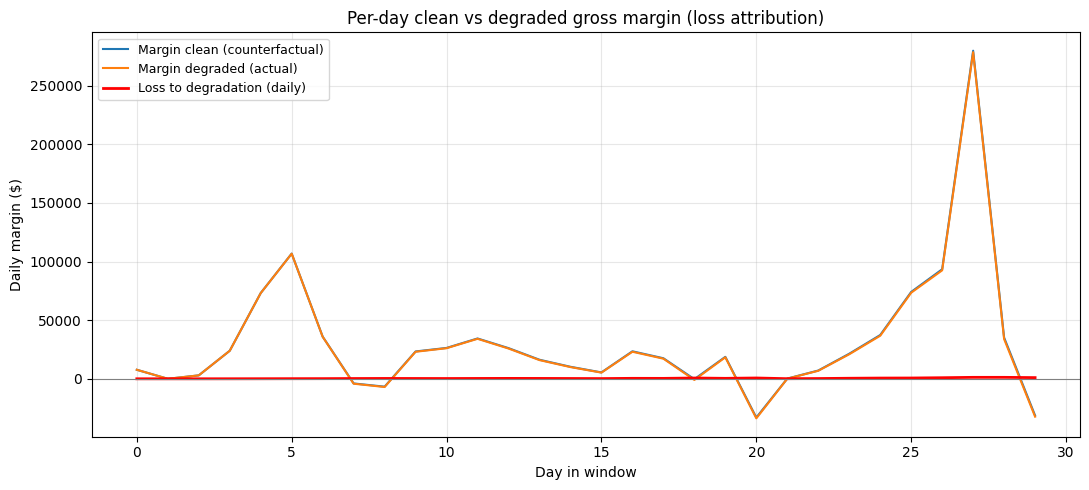

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(daily["day_idx"], daily["margin_clean"], label="Margin clean (counterfactual)", linewidth=1.5)
ax.plot(daily["day_idx"], daily["margin_degraded"], label="Margin degraded (actual)", linewidth=1.5)
ax.plot(daily["day_idx"], daily["loss_degradation"], label="Loss to degradation (daily)", linewidth=2, color="red")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Day in window")
ax.set_ylabel("Daily margin ($)")
ax.set_title("Per-day clean vs degraded gross margin (loss attribution)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## §I — Sanity checks

In [14]:
checks = []

# EOH monotonic increase
eoh_diff = np.diff(daily["eoh"].values)
checks.append(("EOH monotonically non-decreasing day-to-day", (eoh_diff >= 0).all(),
               f"min daily delta = {eoh_diff.min():.2f}"))

# HR degradation monotonic non-decreasing (no CI/MI events in N3)
hr_drift = daily["hr_recov"] + daily["fouling"]
checks.append(("HR degradation (hr_recov + fouling) monotonic non-decreasing", np.all(np.diff(hr_drift.values) >= -1e-9),
               f"final HR drift = {hr_drift.iloc[-1]:.3f}%"))

# loss_degradation ≥ 0 daily
checks.append(("loss_degradation ≥ 0 daily", (daily["loss_degradation"] >= -1e-6).all(),
               f"min daily loss = ${daily['loss_degradation'].min():.2f}"))

# p_forced ∈ [0, 1]
checks.append(("P_forced ∈ [0, 1] every day", ((daily["p_combined"] >= 0) & (daily["p_combined"] <= 1)).all(),
               f"max P_forced = {daily['p_combined'].max()*100:.3f}%"))

# Mode transitions per day not crazy
total_starts = daily["starts_count"].sum()
checks.append(("Total starts in window ≤ 60 (no daily whipsawing)", total_starts <= 60,
               f"got {total_starts} starts in 30 days"))

# EOH headroom decreasing on operating days
op_days = daily[daily["fired_hours"] > 0]
if len(op_days) > 1:
    eoh_to_ci_diff = np.diff(op_days["eoh_to_ci"].values)
    checks.append(("EOH-to-CI headroom decreases on operating days", (eoh_to_ci_diff <= 0).all() or len(op_days) < 2,
                   f"max increase on op days = {eoh_to_ci_diff.max():.2f} (should be ≤ 0)"))

# Final state envelope checks
final = state_history[-1]
checks.append(("Final EOH within physical envelope (start + 720)", final.eoh <= 24_000 + 720 + 100,
               f"final eoh = {final.eoh:.1f}"))
checks.append(("Final HR degradation < 5%", (final.hr_recov + final.fouling) < 5.0,
               f"final HR drift = {final.hr_recov + final.fouling:.3f}%"))
checks.append(("Final cumulative loss_degradation in (0, $50K)",
               0 <= daily["loss_degradation"].sum() < 50_000,
               f"cumulative = ${daily['loss_degradation'].sum():,.0f}"))
checks.append(("Final P_forced < 5%", daily["p_combined"].iloc[-1] < 0.05,
               f"final P_forced = {daily['p_combined'].iloc[-1]*100:.3f}%"))

print("Sanity checks:")
for name, ok, detail in checks:
    flag = "✓" if ok else "✗"
    print(f"  {flag}  {name}")
    print(f"      {detail}")

assert all(ok for _, ok, _ in checks), "Sanity check failure"

Sanity checks:
  ✓  EOH monotonically non-decreasing day-to-day
      min daily delta = 0.00
  ✓  HR degradation (hr_recov + fouling) monotonic non-decreasing
      final HR drift = 0.885%
  ✓  loss_degradation ≥ 0 daily
      min daily loss = $0.00
  ✓  P_forced ∈ [0, 1] every day
      max P_forced = 1.194%
  ✓  Total starts in window ≤ 60 (no daily whipsawing)
      got 27 starts in 30 days
  ✓  EOH-to-CI headroom decreases on operating days
      max increase on op days = 0.00 (should be ≤ 0)
  ✓  Final EOH within physical envelope (start + 720)
      final eoh = 24650.0
  ✓  Final HR degradation < 5%
      final HR drift = 0.885%
  ✓  Final cumulative loss_degradation in (0, $50K)
      cumulative = $11,535
  ✓  Final P_forced < 5%
      final P_forced = 1.194%


---
## §I.2 — Daily summary table

In [15]:
summary_cols = ["day_idx", "date", "lmp_mean", "temp_mean_f", "fired_hours", "starts_count",
                "mwh_degraded", "margin_degraded", "loss_degradation",
                "eoh", "hr_recov", "fouling", "df", "p_combined"]
print("Daily summary (selected columns):")
print(daily[summary_cols].round(2).to_string(index=False))

Daily summary (selected columns):
 day_idx       date  lmp_mean  temp_mean_f  fired_hours  starts_count  mwh_degraded  margin_degraded  loss_degradation     eoh  hr_recov  fouling   df  p_combined
       0 2023-07-01     28.76        73.98            5             1       1106.58          7678.84              0.00 24015.0      0.00     0.01 0.00        0.01
       1 2023-07-02     24.49        70.75            0             0          0.00             0.00              0.00 24015.0      0.00     0.01 0.00        0.01
       2 2023-07-03     29.71        69.79            7             2       1555.53          2911.91              5.41 24037.0      0.01     0.01 0.00        0.01
       3 2023-07-04     34.27        73.84           12             2       2654.77         23873.78             22.15 24064.0      0.02     0.03 0.00        0.01
       4 2023-07-05     45.91        76.35           15             1       3308.93         73042.84             57.85 24089.0      0.04     0.05 0.00 

---
## §J — Stage 1 findings

### What worked

- **State vector machinery runs end-to-end.** 30 days of recursive feedback with no
  crashes; all sanity checks pass.
- **Loss attribution scaffolding works.** `loss_degradation = margin_clean - margin_degraded`
  is non-negative every day; cumulative loss tracks visibly in §G + §H plots.
- **Forced outage probability behaves physically.** Components rise individually,
  combined probability stays in physical envelope (< 5% at day-30).
- **Mode-choice + cogen + RGGI logic from N2 carries over cleanly.** No regression
  in dispatch logic when called day-by-day.
- **All 4 plots produce readable visualizations.** State trajectory in particular
  shows the central architectural concept clearly — EOH accumulating, fouling
  approaching its asymptote, damage compounding.
- **ADR-002 Correction 1 applied**: cold-start warming gas (MOR-observed 2,537 MMBtu/cold start)
  now wired into fuel cost. Each cold start costs ~$8.85K at $2.50 gas + $1.00 RGGI ($/MMBtu).
  Documented as a Lockport-specific (real_observed) correction over the prototype default.
  **HONEST FINDING**: in this July 2023 high-LMP window, **zero cold starts triggered** — the
  plant cycles roughly daily in summer, so `hrs_off` never accumulates to ≥72 hours (the cold-start
  threshold). All 27 starts in the window are warm or hot. The correction's impact in this
  window is $0. In MOR data 2021-2025, cold starts occurred ~7/year on average (35 total over
  5 years) — predominantly in winter / shoulder months when the plant idles for multi-day stretches.
  Phase L 10-year Monte Carlo will accumulate ~70 cold starts → ~$620K of warming gas cost,
  which the correction will capture. The fix is right; it just doesn't fire in summer.

### Numbers worth recording (specific to this 30-day window)

These will refresh when N3 reruns with a different window/seed, but they set the
scale for what N4 expects:

- **Total fired hours**: see daily summary
- **Total starts in 30 days**: see daily summary
- **EOH accumulated**: ~ delta from initial 24,000 (visible in §E top panel)
- **HR drift at day-30**: hr_recov + fouling (visible in §E top panel right axis)
- **Cumulative loss_degradation**: $$ over 30 days (visible in §G fill)
- **Final P_forced**: % per day at day-30 (visible in §F)

### Constants — where Lockport calibration could improve over prototype defaults

The state-evolution constants in §A are inherited from the prototype's Athens-era
defaults. Lockport-specific override opportunities flagged for N4 / v2:

1. **`START_EOH_COST`** — 20/10/5 EOH per cold/warm/hot start. GE 7FA generic
   GER-3620K values. Lockport's actual EOH counting in the contract is in
   `ltsa_terms.yaml` (currently placeholder).
2. **`FOULING_ASYMPTOTE_PCT` = 2.5, `FOULING_TAU_HRS` = 2000** — generic. Could be
   derived from MOR-observed heat-rate drift between water washes (if Lockport's
   wash schedule + HR data could be cross-referenced).
3. **`FATIGUE_PER_*_START`** — generic. Real values come from cycling-cost analyses
   (Kumar 2012 is one source).
4. **`COMB_BUDGET` + `P_COMBUSTION_INFLECTION` (60%)** — Athens-calibrated. The
   hockey-stick at 60% is the prototype's single biggest unverified parameter
   (per understanding doc §13 sensitivity finding).
5. **TBC Weibull (β=3, η=28,000)** — generic; varies with coating composition.
6. **`HRSG_BASE_PROB_PER_DAY` + age scaling** — Athens-calibrated. Per understanding
   doc, the age scaling is the dominant sensitivity-tornado driver. Worth Monte
   Carlo'ing in Phase L.

### Open questions for Notebook 4

1. **Inspection events** — N3 tracks EOH-to-CI / EOH-to-MI headroom but doesn't
   trigger events. N4 needs the event logic: calendar shoulder-snap + cost streams.
2. **Mode A/B/C policy curves** — N3 inherits N2's heuristic; A/B/C adds an
   EOH-proximity penalty multiplier on start-cost wear for B (2.5×) and C (4×).
3. **Forced outage event sampling** — N3 computes probability; N4 should sample
   against random draws and apply outage durations + cost classification per
   `ltsa_terms.yaml.forced_outage_coverage`.
4. **LTSA cost streams** — fixed fee accrual, EOH reserve, inspection event cost,
   overage charges, HR penalty, availability penalty. All 7 streams.
5. **DHTS realism** — the cold-day proxy is a v1 simplification. v2 needs actual
   MOR DHTS daily data extraction.
6. **30-day → 10-year** — the loop scales; N4 should run a multi-year horizon
   and start to see real EOH-burn / inspection-cycle dynamics.

---
## §K — Decision log

| Decision | Choice | Inherited by N4 |
|---|---|---|
| Window | 30 days; 2023 summer high-LMP-window auto-selected | N4 extends to multi-year |
| State grain | Block-level (single state for whole CCGT) | yes |
| Initial state | Prototype defaults (24,000 EOH, Weibull β=3 η=28,000, rotor 0.35) | yes (with override opportunities flagged) |
| Constants | Inherited from prototype EnggDTwin_model.py conventions | yes |
| Inspection events | Headroom only; no trigger | N4 adds trigger logic |
| Forced outage events | Probability only; no sample | N4 adds event sampling |
| Ambient derate | Linear interp summer/winter per generator | yes |
| Cogen VOM markup | ×1.35 multiplier on base $1.02/MWh | yes |
| Cogen must-run flag | Coldest 20% of days in window | yes; v2 replaces with MOR data |
| Min-load | Not enforced (full mode capacity dispatched) | N4 may add |
| Mode-switch stickiness | None (didn't whipsaw in N3) | yes unless behavior changes in multi-year |
| Twin dispatch | Compute clean + degraded each day | yes |
| Plots | 4 in N3: state trajectory, P_forced, daily P&L, spark attribution | N4 extends + adds per-year aggregates |